In [15]:
from pathlib import Path
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import optuna
from sklearn.model_selection import RandomizedSearchCV

/Users/aangphurbasherpa/Desktop/NYC Taxi Duration/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DATA_DIR = Path.cwd().parent / "data"
df = pd.read_csv(DATA_DIR / "processed" / "cleaned_taxi_data.csv")
df.head(5)

,index_left,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,BoroName
0,4217,id1693416,2,2016-01-12 22:57:13,2016-01-12 23:33:06,1,-73.979324,40.727631,-74.074028,40.640224,N,35.883333,Staten Island
1,16494,id1973056,2,2016-03-22 15:35:52,2016-03-22 16:53:17,1,-73.789642,40.647121,-74.135986,40.624981,N,77.416667,Staten Island
2,17985,id3759847,2,2016-02-04 22:00:26,2016-02-04 22:48:18,2,-73.984749,40.742130,-74.076393,40.599159,N,47.866667,Staten Island
3,19015,id3330882,2,2016-04-02 08:47:43,2016-04-02 08:50:23,1,-74.073433,40.615421,-74.073433,40.615421,N,2.666667,Staten Island
4,19701,id0778469,1,2016-01-01 19:46:50,2016-01-01 20:33:26,1,-73.991974,40.749928,-74.115303,40.574230,N,46.600000,Staten Island


In [4]:
def haversine_form(lat1,long1,lat2,long2):
    lat1 , long1,lat2,long2 = map(np.radians, [lat1, long1, lat2, long2])
    dlat = lat2-lat1
    dlong = long2-long1
    a  = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2)*np.sin(dlong/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 3956
    return c*r

In [5]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df.drop(['vendor_id','dropoff_datetime','store_and_fwd_flag'],axis =1,inplace=True)
df['distance'] =  haversine_form(df['pickup_latitude'],df['pickup_longitude'],df['dropoff_latitude'],df['dropoff_longitude'])
df['day_of_week'] = df['pickup_datetime'].dt.day_of_week
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['is_rush_hour'] = df['pickup_hour'].isin([7,8,9,16,17,18,19]).astype(int)
df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1442002 entries, 0 to 1442001
Data columns (total 15 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   index_left         1442002 non-null  int64         
 1   id                 1442002 non-null  str           
 2   pickup_datetime    1442002 non-null  datetime64[us]
 3   passenger_count    1442002 non-null  int64         
 4   pickup_longitude   1442002 non-null  float64       
 5   pickup_latitude    1442002 non-null  float64       
 6   dropoff_longitude  1442002 non-null  float64       
 7   dropoff_latitude   1442002 non-null  float64       
 8   trip_duration      1442002 non-null  float64       
 9   BoroName           1442002 non-null  str           
 10  distance           1442002 non-null  float64       
 11  day_of_week        1442002 non-null  int32         
 12  pickup_hour        1442002 non-null  int32         
 13  is_rush_hour       1442002 non-null  i

In [17]:
df['BoroName']=df['BoroName'].astype("category")

In [18]:
X = df.drop(['trip_duration','id','pickup_datetime','index_left'],axis=1)
y = df['trip_duration']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,shuffle=True)

In [33]:

def objective(trial):


    param = {
        "objective": "reg:absoluteerror",
        "enable_categorical":True,
        "lambda": trial.suggest_float("lambda", 1e-8, 1.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-8, 1.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.2, 1.0),
        "max_depth" :trial.suggest_int("max_depth",1,10),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.2, 1.0),
    }

    model = xgb.XGBRegressor(**param,n_jobs=-1)
    model.fit(X_train.iloc[:50000],y_train.iloc[:50000])
    prediction = model.predict(X_test.iloc[:20000])

    return mean_absolute_error(y_test.iloc[:20000],prediction)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(storage="sqlite:///db.sqlite3",study_name="xgboost_optuna",direction='minimize')
study.optimize(objective, n_trials=100,show_progress_bar=True)
print(study.best_params)
print(study.best_value)

Best trial: 63. Best value: 3.16668: 100%|██████████| 100/100 [02:17<00:00,  1.37s/it]

{'lambda': 3.3633401045158903e-07, 'alpha': 0.01121276561148217, 'subsample': 0.9405758686374284, 'max_depth': 7, 'colsample_bytree': 0.9054986003043914}
3.16667544350485


In [34]:
model = xgb.XGBRegressor(**study.best_params,
                         enable_categorical=True,
                         random_state=42)
model.fit(X_train,y_train)
prediction = model.predict(X_test)
train_p = model.predict(X_train)
print(f"MAE train {mean_absolute_error(y_train,train_p)}| MAE test {mean_absolute_error(y_test,prediction)}")
print(f"R2 {r2_score(y_test,prediction)}")

MAE train 3.02303283446279| MAE test 3.101166383847517
R2 0.7952366732909152


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

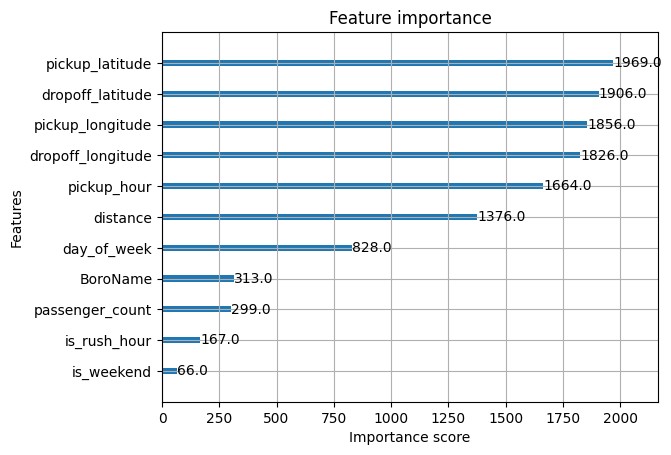

In [35]:
xgb.plot_importance(model)